In [ ]:
"""
The goal of this is to use the normal equation to find weights w for a polynomial regression.
I will build on from there as needed.

https://www.youtube.com/watch?v=ylGlukByeoY&t=1220s
"""

'\nThe goal of this is to use the normal equation to find weights w for a polynomial regression.\nI will build on from there as needed.\n'

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x = np.array([1, 2, 1.5, 3])
y = np.array([1, 1, 0, 2])

# phi should be ax^2 + bx + c1 as my standard equation
phi = np.array([[1 ** 2, 1, 1], [2 ** 2, 2, 1], [1.5 **2, 1.5, 1], [3 ** 2, 3, 1]]) # Manual
phi = np.column_stack([x**2, x, np.ones(len(x))]) # Automatic way to generate

w = np.linalg.inv(phi.T @ phi) @ phi.T @ y


array([ 0.81818182, -2.64545455,  2.63636364])

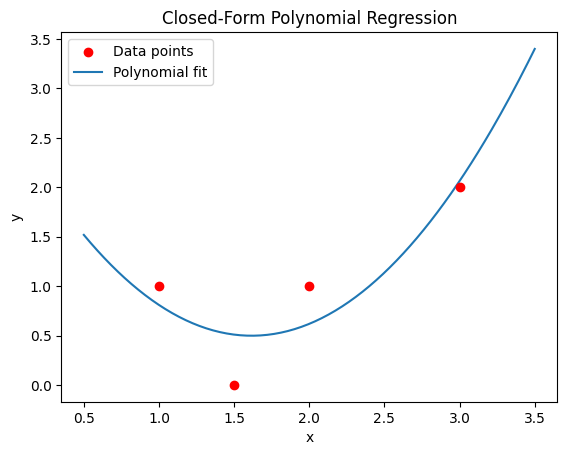

In [6]:
x_plot = np.linspace(0.5, 3.5, 200)
y_plot = w[0]*x_plot**2 + w[1]*x_plot + w[2]

plt.scatter(x, y, color='red', zorder=5, label='Data points')
plt.plot(x_plot, y_plot, label='Polynomial fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Closed-Form Polynomial Regression')
plt.legend()
plt.show()

In [25]:
from sklearn.preprocessing import PolynomialFeatures

a = np.array([1.0, 2.0, 3.0, 1.0, 2.0, 3.0, 1.5, 2.5, 3.5, 4.0])
b = np.array([1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 1.5, 1.5, 1.5, 2.0])
z = np.array([4.1, 6.8, 12.2, 5.3, 8.1, 13.4, 5.9, 9.6, 15.9, 20.2])

X = np.column_stack([a, b])

poly = PolynomialFeatures(2)
phi = poly.fit_transform(X)

w = np.linalg.inv(phi.T @ phi) @ phi.T @ z

w


array([ 2.4969697 , -0.15454545,  0.37878788,  1.07272727, -0.10909091,
        0.34545455])

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X, z)
w = reg.coef_
w

phi_reg = LinearRegression(fit_intercept=False).fit(phi, z)  # w_phi should be equivalent to our w above
w_phi = phi_reg.coef_ 
w_phi 

array([ 2.4969697 , -0.15454545,  0.37878788,  1.07272727, -0.10909091,
        0.34545455])

In [28]:
prediction =  phi @ w_phi

mse = 1/len(prediction) * np.sum((prediction - z)**2)
mse 

np.float64(0.016242424242424294)

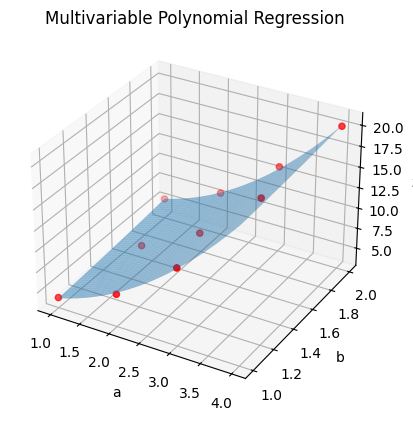

In [12]:
a_grid = np.linspace(a.min(), a.max(), 50)
b_grid = np.linspace(b.min(), b.max(), 50)
A_grid, B_grid = np.meshgrid(a_grid, b_grid)

X_grid = np.column_stack([A_grid.ravel(), B_grid.ravel()])
phi_grid = poly.transform(X_grid)
Z_grid = (phi_grid @ w).reshape(A_grid.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(a, b, z, color='red', zorder=5, label='Data points')
ax.plot_surface(A_grid, B_grid, Z_grid, alpha=0.5)

ax.set_xlabel('a')
ax.set_ylabel('b')
ax.set_zlabel('z')
ax.set_title('Multivariable Polynomial Regression')
plt.show()

In [30]:
import pandas as pd
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

df.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X = df[['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']]

scaled_X = scaler.fit_transform(X)

scaled_X



array([[ 0.80050009,  1.06548848,  1.29708846, ..., -0.05449919,
         0.41853093, -0.37098854],
       [-0.03956713, -0.93853666, -1.08218016, ..., -0.83030083,
        -1.43658851, -1.93847913],
       [ 1.79330681,  1.06548848,  0.93453324, ..., -0.05449919,
         0.06015558, -0.54515416],
       ...,
       [ 0.87686984,  1.06548848, -0.33441002, ..., -0.23293356,
        -0.98564884,  0.32567395],
       [-0.9560041 , -0.93853666,  0.82123474, ...,  0.55838411,
         0.93616291, -0.54515416],
       [-0.9560041 , -0.93853666, -1.53537419, ..., -0.83030083,
        -0.08875225,  0.06442552]])

In [ ]:
lin_reg = LinearRegression().fit(scaled_X, df['target'])
w = lin_reg.coef_

predictions = lin_reg.predict(scaled_X)

df['prediction'] = predictions

mse = 1/len(predictions) * np.sum((predictions - df['target'])**2)

np.float64(2859.69634758675)

In [57]:
poly = PolynomialFeatures(2)
phi = poly.fit_transform(scaled_X)

poly_reg = LinearRegression(fit_intercept=False).fit(phi, df['target'])
predictions = poly_reg.predict(phi)

mse = 1/len(predictions) * np.sum((predictions - df['target'])**2)
mse

np.float64(2416.782257296982)